# 06 — Robustness checks for the EGARCH-X / GARCHND results

Four diagnostic checks to decide whether the **κ=50% GARCHND** result is genuine
economic signal or an artifact:

1. **Out-of-sample forecasting** — does the model beat GARCH(1,1) at $h \in \{1,5,22\}$ on QLIKE/MSE? Diebold-Mariano test against the baseline.
2. **Placebo / regime-only test** — replace $\gamma\, d_3\, x^2_{t-1}$ with $\gamma\, d_3$ alone (regime intercept only) or with a shuffled placebo regressor. If the bare regime dummy captures the same fit improvement, the "news effect" is regime mean-reversion, not sentiment.
3. **SE stability across sigmoid sharpness $K$** — refit the κ=50% models at $K \in \{5, 10, 20, 50, \text{hard}\}$ and check robust sandwich SE + Hessian condition number. Stable across $K$ ⇒ significance is real; unstable ⇒ artifact of smoothing.
4. **Cluster count for κ=50% regime** — count distinct episodes (contiguous runs) where $\sigma^2_{t-1} \geq \kappa_{\text{high}}$. Few clusters ⇒ i.i.d. t-stats overstate evidence; need block-bootstrap or HAC with large bandwidth.

Models in focus: **GARCHND κ=50% Student-t** with $x \in \{\text{tone}, \text{log\_art\_growth}\}$. Benchmark: GARCH(1,1) Student-t.

In [27]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import norm
from statsmodels.tools.numdiff import approx_hess
from arch import arch_model
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

IN_PATH = '../CLEANED DATA/REMX_prices_sentiment_combined.xlsx'
df = (pd.read_excel(IN_PATH, parse_dates=['Date'])
        .sort_values('Date').reset_index(drop=True).set_index('Date'))
df['r'] = np.log(df['Close']/df['Close'].shift(1))
df['r'] = df['r'] - df['r'].mean()
df = df.dropna(subset=['r', 'tone_mean', 'log_art_growth', 'RV_rs']).copy()

# Scale to percent units for numerical stability (matches notebooks 03 / 04)
r_pct    = df['r'].values * 100.0
tone     = df['tone_mean'].values
log_artg = df['log_art_growth'].values
# RV_rs from Rogers–Satchell is in (log-return)^2 units. Convert to %^2/day
# so it lives on the same scale as σ²(GARCH) fitted on r_pct.
RV_pct2  = df['RV_rs'].values * 1e4

print(f'T = {len(df)} obs from {df.index.min().date()} to {df.index.max().date()}')
print(f'r_pct² mean = {(r_pct**2).mean():.3f}   RV_pct2 mean = {RV_pct2.mean():.3f}  '
      f'(should be in the same ballpark; ratio = {RV_pct2.mean()/(r_pct**2).mean():.2f})')

# κ thresholds (from notebook 03)
def ann_vol_to_daily_var(v_ann_pct):
    return (v_ann_pct / np.sqrt(252.0)) ** 2

KAPPA_LOW  = ann_vol_to_daily_var(30.0)
KAPPA_HIGH = ann_vol_to_daily_var(50.0)
print(f'κ_low  = {KAPPA_LOW:.4f}   κ_high = {KAPPA_HIGH:.4f}  (in %²/day)')

SMOOTH_K_DEFAULT = 20.0
PARAM_NAMES = ['omega', 'alpha', 'beta', 'gamma', 'nu']

T = 2765 obs from 2015-04-02 to 2026-03-31
r_pct² mean = 5.250   RV_pct2 mean = 2.050  (should be in the same ballpark; ratio = 0.39)
κ_low  = 3.5714   κ_high = 9.9206  (in %²/day)


## Shared MLE machinery

`garchnd_per_obs_ll` and `garchnd_fit` reproduce the recursion from notebook 03 with two configurable extras:

- `smooth_k` for the sigmoid sharpness, or `hard=True` for the indicator $d_3 = \mathbb{1}\{\sigma^2_{t-1} \geq \kappa\}$;
- `gamma_only=True` to fit the regime-intercept variant $\sigma^2_t = \omega + \alpha r^2_{t-1} + \beta \sigma^2_{t-1} + \gamma\, d_3$ (no $x^2$), used in Check 2.

Sandwich SEs and the Hessian condition number are computed at every fit so we can read them off in Check 3.

In [28]:
def _t_logpdf(z, nu):
    const = gammaln((nu+1)/2.0) - gammaln(nu/2.0) - 0.5*np.log(np.pi*(nu-2.0))
    return const - 0.5*(nu+1)*np.log1p(z**2/(nu-2.0))

def _d3(diff, smooth_k, hard):
    if hard:
        return 1.0 if diff >= 0 else 0.0
    return 1.0 / (1.0 + np.exp(-smooth_k * diff))

def garchnd_per_obs_ll(params, r, x, kappa, smooth_k=20.0, hard=False, gamma_only=False):
    omega, alpha, beta, gamma, nu = params
    n = len(r)
    sig2 = np.empty(n)
    sig2[0] = max(np.var(r), 1e-8)
    for t in range(1, n):
        d3 = _d3(sig2[t-1] - kappa, smooth_k, hard)
        news = gamma * d3 if gamma_only else gamma * d3 * x[t-1]**2
        s = omega + alpha*r[t-1]**2 + beta*sig2[t-1] + news
        sig2[t] = s if s > 1e-8 else 1e-8
    z = r / np.sqrt(sig2)
    ll_t = _t_logpdf(z, nu) - 0.5*np.log(sig2)
    return ll_t, sig2

def garchnd_fit(r, x, kappa, smooth_k=20.0, hard=False, gamma_only=False, x0=None,
                compute_se=True):
    if x0 is None:
        x0 = np.array([0.086, 0.089, 0.898, 0.01, 8.0])
    bounds = [(1e-8, None), (0.0, 0.999), (0.0, 0.999), (None, None), (2.05, 100.0)]

    def neg_ll(p, r, x):
        ll_t, _ = garchnd_per_obs_ll(p, r, x, kappa, smooth_k, hard, gamma_only)
        return -ll_t.sum()

    if hard:
        opt = minimize(neg_ll, x0, args=(r, x), method='Nelder-Mead',
                       options={'maxiter': 30000, 'xatol': 1e-7, 'fatol': 1e-7})
    else:
        opt = minimize(neg_ll, x0, args=(r, x), method='L-BFGS-B',
                       bounds=bounds, options={'maxiter': 5000})
        opt2 = minimize(neg_ll, opt.x, args=(r, x), method='Nelder-Mead',
                        options={'maxiter': 10000, 'xatol': 1e-7, 'fatol': 1e-7})
        if opt2.fun < opt.fun:
            opt = opt2

    theta = opt.x
    ll = -opt.fun

    se = np.full(5, np.nan)
    hess_cond = np.nan
    if compute_se:
        try:
            H = approx_hess(theta, neg_ll, args=(r, x))
            V_hess = np.linalg.inv(H)
            eps_fd = 1e-5
            n = len(r)
            G = np.empty((n, len(theta)))
            for i in range(len(theta)):
                up = theta.copy(); up[i] += eps_fd
                dn = theta.copy(); dn[i] -= eps_fd
                ll_up, _ = garchnd_per_obs_ll(up, r, x, kappa, smooth_k, hard, gamma_only)
                ll_dn, _ = garchnd_per_obs_ll(dn, r, x, kappa, smooth_k, hard, gamma_only)
                G[:, i] = (ll_up - ll_dn) / (2*eps_fd)
            V_robust = V_hess @ (G.T @ G) @ V_hess
            se = np.sqrt(np.abs(np.diag(V_robust)))
            eigs = np.linalg.eigvalsh(H)
            hess_cond = float(abs(eigs).max() / max(abs(eigs).min(), 1e-12))
        except Exception:
            pass

    _, sig2 = garchnd_per_obs_ll(theta, r, x, kappa, smooth_k, hard, gamma_only)
    aic = -2*ll + 2*len(theta)
    bic = -2*ll + len(theta)*np.log(len(r))
    return dict(theta=theta, ll=ll, aic=aic, bic=bic, se=se,
                hess_cond=hess_cond, sig2=sig2, converged=opt.success)

## Check 1 — Out-of-sample forecasting

In-sample fit through 2025-03-31 (matches the HAR split in notebook 05). OOS evaluation on the remaining trading days.

- **Target**: average realized variance $\overline{RV}_{t,t+h} = \frac{1}{h}\sum_{k=1}^{h} RV^{rs}_{t+k}$ (in %²/day), for $h \in \{1, 5, 22\}$.
- **Forecast**: iterated $h$-step ahead conditional variance. $\sigma^2_{t+1}|F_t$ uses observed lags $r_t, \sigma^2_t, x_t$; for $k \geq 2$ we use $\sigma^2_{t+k}|F_t = \omega + (\alpha+\beta)\, \sigma^2_{t+k-1}|F_t$ (future $x = 0$, so the $\gamma$ term zeroes out beyond the first step).
- **Losses**: **QLIKE** $L = \log(\sigma^2) + RV / \sigma^2$ (primary — robust to noisy RV proxies, Patton 2011) and **MSE** $L = (RV - \sigma^2)^2$ (secondary — biased by RV noise but reported for comparison).
- **Diebold-Mariano** vs the GARCH(1,1) baseline at each $h$, with Newey-West lag $= h-1$.

**Refit cadence**: single in-sample fit (static parameters during OOS). Periodic refit is straightforward to add but is unlikely to flip conclusions over a ~1-year window.

In [29]:
# ============================================================
# Check 1 (revised) — Rolling-window OOS forecasting
# OOS:    2023-01-03 -> 2026-03-31  (813 trading days)
# Window: 1,260 days, re-estimated daily
# Models: GARCH(1,1) Student-t baseline, GARCHND κ=50% (x=tone, x=log_art_growth)
# Proxies: RV_park (Parkinson) and RV_rs (Rogers–Satchell), both in %²/day
# Losses: HRMSE, QLIKE, RMSE, MAE
# Tests:  DM (two-sided) and Clark–West (one-sided) vs GARCH(1,1), NW lag = h-1
# ============================================================
import time
import scipy.stats as stats

OOS_START = pd.Timestamp('2023-01-03')
OOS_END   = pd.Timestamp('2026-03-31')
WINDOW    = 1260
HORIZONS  = [1, 5, 22]

RV_park_pct2 = df['RV_park'].values * 1e4
RV_rs_pct2   = df['RV_rs'].values   * 1e4
RV_PROXIES = {'Parkinson': RV_park_pct2, 'Rogers-Satchell': RV_rs_pct2}

dates_arr      = df.index
oos_target_pos = np.where((dates_arr >= OOS_START) & (dates_arr <= OOS_END))[0]
T_oos          = len(oos_target_pos)
print(f'OOS targets: {dates_arr[oos_target_pos[0]].date()} -> '
      f'{dates_arr[oos_target_pos[-1]].date()}  ({T_oos} days)')
print(f'Rolling window: {WINDOW} days, daily refit')

# ---- loss functions ----
def hrmse_loss(y, yhat):
    m = y != 0
    return float(np.sqrt(np.mean(((y[m] - yhat[m]) / y[m])**2)))
def qlike_loss(y, yhat): return float(np.mean(np.log(yhat) + y / yhat))
def rmse_loss(y, yhat):  return float(np.sqrt(np.mean((y - yhat)**2)))
def mae_loss(y, yhat):   return float(np.mean(np.abs(y - yhat)))

# ---- HAC variance of sample mean (Bartlett) ----
def nw_var_mean(x, lag):
    x = np.asarray(x, float); x = x - x.mean(); n = len(x)
    v = float(np.sum(x * x) / n)
    for l in range(1, lag + 1):
        w = 1.0 - l / (lag + 1.0)
        v += 2.0 * w * float(np.sum(x[l:] * x[:-l]) / n)
    return v / n

def dm_test_h(y, f_base, f_model, lag):
    """Two-sided DM on squared-loss differential. DM>0 ⇒ candidate has lower MSE."""
    d = (y - f_base) ** 2 - (y - f_model) ** 2
    var_d = nw_var_mean(d, lag)
    if var_d <= 0: return np.nan, np.nan
    dm = d.mean() / np.sqrt(var_d)
    return float(dm), float(2 * (1 - stats.norm.cdf(abs(dm))))

def clark_west(y, f_base, f_model, lag):
    """One-sided Clark–West for nested models. CW>0 ⇒ candidate beats baseline."""
    f = (y - f_base) ** 2 - ((y - f_model) ** 2 - (f_base - f_model) ** 2)
    var_f = nw_var_mean(f, lag)
    if var_f <= 0: return np.nan, np.nan
    t = f.mean() / np.sqrt(var_f)
    return float(t), float(1 - stats.norm.cdf(t))

# ---- fast GARCHND fit: L-BFGS-B only, no SE, warm-started ----
def garchnd_fit_fast(r, x, kappa, x0, smooth_k=SMOOTH_K_DEFAULT):
    bounds = [(1e-8, None), (0.0, 0.999), (0.0, 0.999), (None, None), (2.05, 100.0)]
    def neg_ll(p, r, x):
        ll_t, _ = garchnd_per_obs_ll(p, r, x, kappa, smooth_k, False, False)
        return -ll_t.sum()
    opt = minimize(neg_ll, x0, args=(r, x), method='L-BFGS-B',
                   bounds=bounds, options={'maxiter': 500})
    return opt.x if opt.success else x0

def garchnd_sig2_last(theta, r, x, kappa, smooth_k=SMOOTH_K_DEFAULT):
    omega, alpha, beta, gamma, nu = theta
    n = len(r); sig2 = np.empty(n); sig2[0] = max(np.var(r), 1e-8)
    for t in range(1, n):
        d3 = 1.0 / (1.0 + np.exp(-smooth_k * (sig2[t-1] - kappa)))
        s = omega + alpha*r[t-1]**2 + beta*sig2[t-1] + gamma*d3*x[t-1]**2
        sig2[t] = s if s > 1e-8 else 1e-8
    return sig2[-1]

def garchnd_iter_forecast(theta, sig2_last, r_last, x_last, kappa, h, smooth_k=SMOOTH_K_DEFAULT):
    """Iterated h-step forecast. Future E[x²]=0, so γ-term drops out for k≥2."""
    omega, alpha, beta, gamma, nu = theta
    out = np.empty(h)
    d3 = 1.0 / (1.0 + np.exp(-smooth_k * (sig2_last - kappa)))
    out[0] = omega + alpha*r_last**2 + beta*sig2_last + gamma*d3*x_last**2
    for k in range(1, h):
        out[k] = omega + (alpha + beta) * out[k-1]
    return out

def garch_sig2_last(omega, alpha, beta, r):
    n = len(r); sig2 = np.empty(n); sig2[0] = max(np.var(r), 1e-8)
    for t in range(1, n):
        s = omega + alpha*r[t-1]**2 + beta*sig2[t-1]
        sig2[t] = s if s > 1e-8 else 1e-8
    return sig2[-1]

def garch_iter_forecast(omega, alpha, beta, sig2_last, r_last, h):
    out = np.empty(h)
    out[0] = omega + alpha*r_last**2 + beta*sig2_last
    for k in range(1, h):
        out[k] = omega + (alpha + beta) * out[k-1]
    return out

# ---- storage ----
preds = {
    'GARCH(1,1)':       {h: np.full(T_oos, np.nan) for h in HORIZONS},
    'GARCHND tone':     {h: np.full(T_oos, np.nan) for h in HORIZONS},
    'GARCHND log_artg': {h: np.full(T_oos, np.nan) for h in HORIZONS},
}
targets = {name: {h: np.full(T_oos, np.nan) for h in HORIZONS} for name in RV_PROXIES}

# ---- warm starts ----
theta_tone_prev = np.array([0.086, 0.089, 0.898, 0.01, 8.0])
theta_artg_prev = np.array([0.086, 0.089, 0.898, 0.01, 8.0])

t0 = time.time()
PROGRESS_EVERY = 50
for i, target_t in enumerate(oos_target_pos):
    tau   = target_t - 1                 # forecast origin
    start = tau - WINDOW + 1
    if start < 0:
        raise RuntimeError(f'Not enough data: need {WINDOW} days before tau={tau}')

    r_w, tone_w, artg_w = r_pct[start:tau+1], tone[start:tau+1], log_artg[start:tau+1]
    r_last, x_tone_last, x_artg_last = r_pct[tau], tone[tau], log_artg[tau]

    # GARCH(1,1) baseline
    bres = arch_model(pd.Series(r_w), mean='Zero', vol='GARCH', p=1, q=1, dist='t').fit(disp='off')
    bw = float(bres.params['omega'])
    ba = float(bres.params['alpha[1]'])
    bb = float(bres.params['beta[1]'])
    sig2_T = garch_sig2_last(bw, ba, bb, r_w)
    for h in HORIZONS:
        preds['GARCH(1,1)'][h][i] = float(garch_iter_forecast(bw, ba, bb, sig2_T, r_last, h).mean())

    # GARCHND κ=50% tone
    theta_tone_prev = garchnd_fit_fast(r_w, tone_w, KAPPA_HIGH, theta_tone_prev)
    sig2_T = garchnd_sig2_last(theta_tone_prev, r_w, tone_w, KAPPA_HIGH)
    for h in HORIZONS:
        preds['GARCHND tone'][h][i] = float(
            garchnd_iter_forecast(theta_tone_prev, sig2_T, r_last, x_tone_last, KAPPA_HIGH, h).mean())

    # GARCHND κ=50% log_art_growth
    theta_artg_prev = garchnd_fit_fast(r_w, artg_w, KAPPA_HIGH, theta_artg_prev)
    sig2_T = garchnd_sig2_last(theta_artg_prev, r_w, artg_w, KAPPA_HIGH)
    for h in HORIZONS:
        preds['GARCHND log_artg'][h][i] = float(
            garchnd_iter_forecast(theta_artg_prev, sig2_T, r_last, x_artg_last, KAPPA_HIGH, h).mean())

    # realised h-period targets (NaN if the last h days are not yet observed)
    for name, rv in RV_PROXIES.items():
        for h in HORIZONS:
            if target_t + h <= len(rv):
                targets[name][h][i] = float(rv[target_t:target_t + h].mean())

    if (i + 1) % PROGRESS_EVERY == 0 or (i + 1) == T_oos:
        el = time.time() - t0
        eta = el / (i + 1) * (T_oos - i - 1)
        print(f'  [{i+1:>4}/{T_oos}]  elapsed {el/60:5.1f} min, ETA {eta/60:5.1f} min')

print(f'Rolling OOS complete in {(time.time()-t0)/60:.1f} min.')


OOS targets: 2023-01-03 -> 2026-03-31  (813 days)
Rolling window: 1260 days, daily refit
  [  50/813]  elapsed   0.2 min, ETA   3.1 min
  [ 100/813]  elapsed   0.4 min, ETA   2.6 min
  [ 150/813]  elapsed   0.5 min, ETA   2.4 min
  [ 200/813]  elapsed   0.7 min, ETA   2.2 min
  [ 250/813]  elapsed   0.9 min, ETA   2.1 min
  [ 300/813]  elapsed   1.1 min, ETA   1.9 min
  [ 350/813]  elapsed   1.3 min, ETA   1.7 min
  [ 400/813]  elapsed   1.4 min, ETA   1.5 min
  [ 450/813]  elapsed   1.6 min, ETA   1.3 min
  [ 500/813]  elapsed   1.8 min, ETA   1.1 min
  [ 550/813]  elapsed   2.0 min, ETA   0.9 min
  [ 600/813]  elapsed   2.2 min, ETA   0.8 min
  [ 650/813]  elapsed   2.4 min, ETA   0.6 min
  [ 700/813]  elapsed   2.5 min, ETA   0.4 min
  [ 750/813]  elapsed   2.7 min, ETA   0.2 min
  [ 800/813]  elapsed   2.9 min, ETA   0.0 min
  [ 813/813]  elapsed   3.0 min, ETA   0.0 min
Rolling OOS complete in 3.0 min.


In [30]:
def full_path_garchnd(theta, r_all, x_all, kappa, smooth_k, T_in):
    omega, alpha, beta, gamma, nu = theta
    n = len(r_all)
    sig2 = np.empty(n)
    sig2[0] = max(np.var(r_all[:T_in]), 1e-8)
    for t in range(1, n):
        d3 = 1.0/(1.0+np.exp(-smooth_k*(sig2[t-1]-kappa)))
        s = omega + alpha*r_all[t-1]**2 + beta*sig2[t-1] + gamma*d3*x_all[t-1]**2
        sig2[t] = s if s > 1e-8 else 1e-8
    return sig2

def full_path_garch(omega, alpha, beta, r_all, T_in):
    n = len(r_all)
    sig2 = np.empty(n)
    sig2[0] = max(np.var(r_all[:T_in]), 1e-8)
    for t in range(1, n):
        s = omega + alpha*r_all[t-1]**2 + beta*sig2[t-1]
        sig2[t] = s if s > 1e-8 else 1e-8
    return sig2

sig2_tone = full_path_garchnd(fit_tone['theta'], r_pct, tone,     KAPPA_HIGH, SMOOTH_K_DEFAULT, T_in)
sig2_artg = full_path_garchnd(fit_artg['theta'], r_pct, log_artg, KAPPA_HIGH, SMOOTH_K_DEFAULT, T_in)
sig2_base = full_path_garch(base_theta['omega'], base_theta['alpha'], base_theta['beta'], r_pct, T_in)

def forecast_h_garchnd(theta, sig2_t, r_t, x_t, kappa, h, smooth_k):
    omega, alpha, beta, gamma, nu = theta
    out = np.empty(h)
    d3 = 1.0/(1.0+np.exp(-smooth_k*(sig2_t-kappa)))
    out[0] = omega + alpha*r_t**2 + beta*sig2_t + gamma*d3*x_t**2
    for k in range(1, h):
        out[k] = omega + (alpha + beta) * out[k-1]
    return out

def forecast_h_garch(omega, alpha, beta, sig2_t, r_t, h):
    out = np.empty(h)
    out[0] = omega + alpha*r_t**2 + beta*sig2_t
    for k in range(1, h):
        out[k] = omega + (alpha + beta) * out[k-1]
    return out

def qlike(rv, sig2):  return np.log(sig2) + rv / sig2
def mse(rv, sig2):    return (rv - sig2) ** 2

def dm_test(loss1, loss2, lag=0):
    """Two-sided DM with Newey-West LRV. DM>0 ⇒ model2 has lower loss ⇒ model2 wins."""
    d = loss1 - loss2
    n = len(d)
    m = d.mean()
    lrv = np.var(d, ddof=1)
    for k in range(1, lag+1):
        w = 1 - k/(lag+1)
        cov_k = np.cov(d[k:], d[:-k], ddof=1)[0,1]
        lrv += 2 * w * cov_k
    se = np.sqrt(max(lrv, 1e-12) / n)
    stat = m / se
    p = 2 * (1 - norm.cdf(abs(stat)))
    return stat, p

def oos_metrics(sig2_path, theta=None, x_path=None, kappa=None, baseline=False):
    results = []
    for h in HORIZONS:
        preds, targets = [], []
        for tau in range(T_in - 1, T - h):
            r_t = r_pct[tau]; sig2_t = sig2_path[tau]
            if baseline:
                fpath = forecast_h_garch(base_theta['omega'], base_theta['alpha'],
                                          base_theta['beta'], sig2_t, r_t, h)
            else:
                fpath = forecast_h_garchnd(theta, sig2_t, r_t, x_path[tau],
                                            kappa, h, SMOOTH_K_DEFAULT)
            preds.append(fpath.mean())
            targets.append(RV_pct2[tau+1:tau+1+h].mean())
        preds = np.array(preds); targets = np.array(targets)
        results.append(dict(h=h, qlike_mean=qlike(targets, preds).mean(),
                            mse_mean=mse(targets, preds).mean(),
                            preds=preds, targets=targets))
    return results

print('Computing OOS forecasts at h ∈ {1, 5, 22} ...')
res_base = oos_metrics(sig2_base, baseline=True)
res_tone = oos_metrics(sig2_tone, theta=fit_tone['theta'], x_path=tone,     kappa=KAPPA_HIGH)
res_artg = oos_metrics(sig2_artg, theta=fit_artg['theta'], x_path=log_artg, kappa=KAPPA_HIGH)

print('\n--- QLIKE / MSE (mean over OOS days) ---')
print(f'{"Model":<28}{"h":>4}{"QLIKE":>12}{"MSE":>14}')
for label, results in [('GARCH(1,1) Student-t (base)', res_base),
                        ('GARCHND tone κ=50%',           res_tone),
                        ('GARCHND log_artg κ=50%',       res_artg)]:
    for r in results:
        print(f'{label:<28}{r["h"]:>4}{r["qlike_mean"]:>12.4f}{r["mse_mean"]:>14.4f}')

print('\n--- Diebold-Mariano (baseline vs candidate; DM>0 ⇒ candidate wins) ---')
print(f'{"Candidate":<28}{"h":>4}{"DM-QLIKE":>12}{"p":>10}{"DM-MSE":>12}{"p":>10}')
for label, res_cand in [('GARCHND tone κ=50%',     res_tone),
                         ('GARCHND log_artg κ=50%', res_artg)]:
    for r_b, r_c in zip(res_base, res_cand):
        h = r_b['h']
        l_b_q = qlike(r_b['targets'], r_b['preds'])
        l_c_q = qlike(r_c['targets'], r_c['preds'])
        l_b_m = mse(r_b['targets'], r_b['preds'])
        l_c_m = mse(r_c['targets'], r_c['preds'])
        stat_q, p_q = dm_test(l_b_q, l_c_q, lag=h-1)
        stat_m, p_m = dm_test(l_b_m, l_c_m, lag=h-1)
        print(f'{label:<28}{h:>4}{stat_q:>+12.3f}{p_q:>10.4f}{stat_m:>+12.3f}{p_m:>10.4f}')

Computing OOS forecasts at h ∈ {1, 5, 22} ...

--- QLIKE / MSE (mean over OOS days) ---
Model                          h       QLIKE           MSE
GARCH(1,1) Student-t (base)    1      2.4225       48.0561
GARCH(1,1) Student-t (base)    5      2.4561       38.7524
GARCH(1,1) Student-t (base)   22      2.3900       29.7071
GARCHND tone κ=50%             1      2.4065       40.0134
GARCHND tone κ=50%             5      2.4437       31.5491
GARCHND tone κ=50%            22      2.3892       26.3860
GARCHND log_artg κ=50%         1      2.3814       37.6968
GARCHND log_artg κ=50%         5      2.4183       29.4843
GARCHND log_artg κ=50%        22      2.3748       25.8023

--- Diebold-Mariano (baseline vs candidate; DM>0 ⇒ candidate wins) ---
Candidate                      h    DM-QLIKE         p      DM-MSE         p
GARCHND tone κ=50%             1      +3.119    0.0018      +6.770    0.0000
GARCHND tone κ=50%             5      +1.465    0.1430      +3.466    0.0005
GARCHND tone κ=50% 

## Check 2 — Placebo / regime-only test

Two alternative specifications fitted alongside the original GARCHND κ=50%:

1. **Regime-only**: $\sigma^2_t = \omega + \alpha r^2_{t-1} + \beta \sigma^2_{t-1} + \gamma\, d_3$. The news term drops the $x^2$ factor entirely — $\gamma$ now measures a regime-conditional intercept shift. If this matches the LL gain of the full model, the contribution is regime mean-reversion, not news.
2. **Placebo**: same model but $x$ is a random permutation of the original series (preserves marginal distribution and squared scale, destroys time alignment). If a placebo achieves a similar $\gamma$ t-ratio, the original $x$ is not informative.

Fit on the full sample. Compare LL/AIC/BIC and the t-ratio on $\gamma$ across `original`, `regime-only`, and 5 placebo seeds.

In [31]:
# ---- 1. Loss-function table (HRMSE, QLIKE, RMSE, MAE) ----
loss_rows = []
for proxy_name in RV_PROXIES:
    for model_name in preds:
        for h in HORIZONS:
            y    = targets[proxy_name][h]
            yhat = preds[model_name][h]
            mask = ~(np.isnan(y) | np.isnan(yhat) | (yhat <= 0))
            y_, f_ = y[mask], yhat[mask]
            loss_rows.append([proxy_name, model_name, h,
                              hrmse_loss(y_, f_), qlike_loss(y_, f_),
                              rmse_loss(y_, f_),  mae_loss(y_, f_),
                              int(mask.sum())])
loss_tbl = pd.DataFrame(loss_rows,
                        columns=['proxy', 'model', 'h', 'HRMSE', 'QLIKE', 'RMSE', 'MAE', 'N'])
print('=== Loss functions (rolling-window OOS, 813 origins) ===')
print(loss_tbl.to_string(index=False, float_format=lambda v: f'{v:10.4f}'))

# ---- 2. Diebold-Mariano and Clark-West vs GARCH(1,1) ----
test_rows = []
for proxy_name in RV_PROXIES:
    for cand in ['GARCHND tone', 'GARCHND log_artg']:
        for h in HORIZONS:
            y    = targets[proxy_name][h]
            f_b  = preds['GARCH(1,1)'][h]
            f_m  = preds[cand][h]
            mask = ~(np.isnan(y) | np.isnan(f_b) | np.isnan(f_m) | (f_b <= 0) | (f_m <= 0))
            y_, fb_, fm_ = y[mask], f_b[mask], f_m[mask]
            dm,  dmp = dm_test_h(y_, fb_, fm_, lag=h-1)
            cw,  cwp = clark_west(y_, fb_, fm_, lag=h-1)
            test_rows.append([proxy_name, cand, h, dm, dmp, cw, cwp])
test_tbl = pd.DataFrame(test_rows,
                        columns=['proxy', 'candidate', 'h', 'DM', 'DM_p', 'CW', 'CW_p'])
print('\n=== Diebold–Mariano (two-sided; DM>0 ⇒ candidate < baseline MSE)')
print('=== Clark–West (one-sided; CW>0 ⇒ candidate adds predictive content vs nested baseline) ===')
print(test_tbl.to_string(index=False, float_format=lambda v: f'{v:+10.4f}'))


=== Loss functions (rolling-window OOS, 813 origins) ===
          proxy            model  h      HRMSE      QLIKE       RMSE        MAE   N
      Parkinson       GARCH(1,1)  1     5.4023     2.0760     4.8866     3.9585 813
      Parkinson       GARCH(1,1)  5     2.9753     2.0933     4.4833     3.7785 809
      Parkinson       GARCH(1,1) 22     2.6582     2.1211     4.1826     3.6778 792
      Parkinson     GARCHND tone  1     5.3128     2.0730     4.7686     3.9090 813
      Parkinson     GARCHND tone  5     2.9460     2.0928     4.3911     3.7591 809
      Parkinson     GARCHND tone 22     2.7032     2.1348     4.2540     3.7962 792
      Parkinson GARCHND log_artg  1     5.3400     2.0750     4.7698     3.9104 813
      Parkinson GARCHND log_artg  5     2.9620     2.0949     4.4162     3.7639 809
      Parkinson GARCHND log_artg 22     2.6966     2.1361     4.3428     3.8460 792
Rogers-Satchell       GARCH(1,1)  1    12.5808     2.0617     4.8178     3.9280 813
Rogers-Satchell    

## Check 3 — SE stability across sigmoid sharpness $K$

Refit both GARCHND κ=50% models at $K \in \{5, 10, 20, 50\}$ (smooth indicator) plus a hard indicator $d_3 = \mathbb{1}\{\sigma^2_{t-1} \geq \kappa\}$.

For each fit report $\hat\gamma$, the robust sandwich SE on $\gamma$, the t-ratio, and the Hessian condition number (max|eigenvalue| / min|eigenvalue|; large ⇒ ill-conditioned, SEs unreliable).

**Reading**:
- $\hat\gamma$ and t-ratio roughly constant across $K$ ⇒ the significance is real.
- SEs blow up or t-ratio swings sign / disappears as $K$ changes ⇒ artifact of the smoothing choice.
- Hessian condition number $> 10^8$ at any $K$ ⇒ likelihood is locally flat in $\gamma$, SEs degenerate.

In [32]:
def stability_table(r, x, kappa, label):
    rows = []
    for k in [5.0, 10.0, 20.0, 50.0]:
        print(f'  fitting K={k:g} ...', end='', flush=True)
        f = garchnd_fit(r, x, kappa, smooth_k=k)
        g_t = f['theta'][3] / max(f['se'][3], 1e-12)
        rows.append([f'K={k:g}', f['ll'], f['theta'][3], f['se'][3], g_t,
                      f['hess_cond'], f['converged']])
        print(' done.')
    print(f'  fitting hard indicator ...', end='', flush=True)
    f_hard = garchnd_fit(r, x, kappa, hard=True)
    g_t = f_hard['theta'][3] / max(f_hard['se'][3], 1e-12)
    rows.append(['hard d3', f_hard['ll'], f_hard['theta'][3], f_hard['se'][3], g_t,
                  f_hard['hess_cond'], f_hard['converged']])
    print(' done.')

    tbl = pd.DataFrame(rows, columns=['smoothness','LL','gamma','SE(gamma)',
                                        't(gamma)','hess_cond','converged'])
    print(f'\n=== {label} ===')
    print(tbl.to_string(index=False, float_format=lambda x: f'{x: .4f}'))
    # Quick verdict
    t_vals = tbl['t(gamma)'].values
    g_vals = tbl['gamma'].values
    cv = float(np.std(g_vals) / max(abs(np.mean(g_vals)), 1e-12))
    print(f'\n  γ̂ coefficient of variation across K: {cv:.3f} '
          f'(<0.2 = stable; >0.5 = unstable)')
    print(f'  t-ratio range: [{t_vals.min():+.2f}, {t_vals.max():+.2f}]')
    if cv < 0.2 and (t_vals > 1.96).all():
        print('  VERDICT: γ̂ stable AND consistently significant → real effect.')
    elif cv > 0.5 or not (np.abs(t_vals) > 1.96).any():
        print('  VERDICT: γ̂ unstable or never significant → artifact of smoothing.')
    else:
        print('  VERDICT: mixed evidence — sensitive to K.')
    return tbl

print('--- Stability across K: GARCHND κ=50% tone ---')
stab_tone = stability_table(r_pct, tone, KAPPA_HIGH, 'GARCHND κ=50% tone')

print('\n--- Stability across K: GARCHND κ=50% log_art_growth ---')
stab_artg = stability_table(r_pct, log_artg, KAPPA_HIGH, 'GARCHND κ=50% log_art_growth')

--- Stability across K: GARCHND κ=50% tone ---
  fitting K=5 ... done.
  fitting K=10 ... done.
  fitting K=20 ... done.
  fitting K=50 ... done.
  fitting hard indicator ... done.

=== GARCHND κ=50% tone ===
smoothness         LL   gamma  SE(gamma)  t(gamma)        hess_cond  converged
       K=5 -5952.6258 -0.3626     0.0737   -4.9227     1405978.7304       True
      K=10 -5952.4179 -0.3769     0.0740   -5.0903     2262854.0416       True
      K=20 -5951.9715 -0.8262     0.0602  -13.7248    92299516.4763       True
      K=50 -5952.1575 -0.3880     0.0008 -468.3107   214175578.4664       True
   hard d3 -5953.2384 -0.3191     0.0989   -3.2267  2406002969.5533       True

  γ̂ coefficient of variation across K: 0.412 (<0.2 = stable; >0.5 = unstable)
  t-ratio range: [-468.31, -3.23]
  VERDICT: mixed evidence — sensitive to K.

--- Stability across K: GARCHND κ=50% log_art_growth ---
  fitting K=5 ... done.
  fitting K=10 ... done.
  fitting K=20 ... done.
  fitting K=50 ... done.
  

## Check 4 — Cluster count for κ=50% regime

Identify days where $\sigma^2_{t-1} \geq \kappa_{\text{high}}$ (the trigger condition for $d_3 = 1$) using the full-sample fitted $\sigma^2$ path. Two consecutive trigger days separated by $\leq$ `GAP_DAYS = 5` non-trigger days are grouped into the same episode.

Report: total triggered days, distinct episode count, top-10 longest episodes with date ranges. Overlay $\sigma^2_t$ vs $\kappa_{\text{high}}$ on a time series plot.

**Reading**: if a handful of episodes (e.g. COVID March 2020, 2021-2022 rare-earth / commodity shocks) dominate, the i.i.d.-style t-stats on $\gamma$ massively overstate the evidence — block-bootstrap or HAC SE with bandwidth ≥ longest episode length are needed.


=== GARCHND κ=50% tone ===
Total triggered days (σ²_{t-1} ≥ κ_high): 110 of 2765 (3.98%)
Distinct episodes (gap ≤ 5 days): 15
Top 10 longest episodes:
  #   start         end             days
  1   2021-02-10    2021-04-01        36
  2   2020-03-11    2020-04-14        24
  3   2025-10-15    2025-11-12        21
  4   2026-03-05    2026-03-30        18
  5   2026-02-03    2026-02-19        12
  6   2025-04-11    2025-04-23         8
  7   2018-12-24    2019-01-02         6
  8   2022-11-08    2022-11-15         6
  9   2024-09-30    2024-10-01         2
  10  2021-01-11    2021-01-11         1

  → Block-bootstrap block length recommendation: ≥ 36 days (longest episode).
  → HAC bandwidth recommendation: ≥ 36 lags.

=== GARCHND κ=50% log_art_growth ===
Total triggered days (σ²_{t-1} ≥ κ_high): 129 of 2765 (4.67%)
Distinct episodes (gap ≤ 5 days): 22
Top 10 longest episodes:
  #   start         end             days
  1   2020-03-04    2020-04-17        32
  2   2021-01-07    2021-02-1

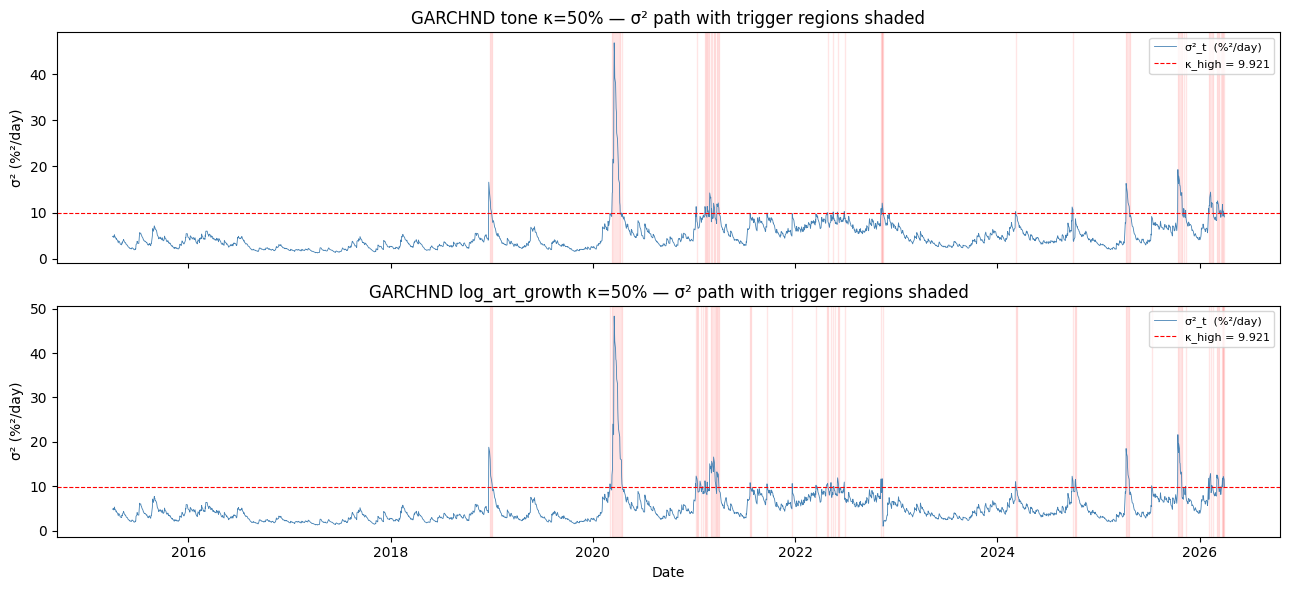

In [33]:
GAP_DAYS = 5

def episode_clusters(sig2_path, kappa, gap=GAP_DAYS):
    # σ²_{t-1} ≥ κ_high activates d_3 at time t
    triggered = np.zeros(len(sig2_path), dtype=bool)
    triggered[1:] = sig2_path[:-1] >= kappa

    clusters = []
    in_run = False
    run_start = last_true = None
    for t, flag in enumerate(triggered):
        if flag:
            if not in_run:
                run_start = t
                in_run = True
            last_true = t
        else:
            if in_run and (t - last_true) > gap:
                clusters.append((run_start, last_true))
                in_run = False
    if in_run:
        clusters.append((run_start, last_true))
    return clusters, triggered

def summarize_clusters(clusters, triggered, dates, label):
    n_days = int(triggered.sum())
    pct = 100*n_days/len(triggered)
    print(f'\n=== {label} ===')
    print(f'Total triggered days (σ²_{{t-1}} ≥ κ_high): {n_days} of {len(triggered)} ({pct:.2f}%)')
    print(f'Distinct episodes (gap ≤ {GAP_DAYS} days): {len(clusters)}')
    if not clusters:
        return []
    sorted_cl = sorted(clusters, key=lambda c: c[1]-c[0], reverse=True)[:10]
    print(f'Top 10 longest episodes:')
    print(f'  {"#":<4}{"start":<14}{"end":<14}{"days":>6}')
    for i, (s, e) in enumerate(sorted_cl, 1):
        print(f'  {i:<4}{str(dates[s].date()):<14}{str(dates[e].date()):<14}{e-s+1:>6}')
    longest = sorted_cl[0][1] - sorted_cl[0][0] + 1
    print(f'\n  → Block-bootstrap block length recommendation: ≥ {longest} days '
          f'(longest episode).')
    print(f'  → HAC bandwidth recommendation: ≥ {max(longest, 22)} lags.')
    if len(clusters) <= 5:
        print(f'  VERDICT: only {len(clusters)} episodes — i.i.d. t-stats overstate evidence.')
    return sorted_cl

clusters_tone, trig_tone = episode_clusters(sig2_tone, KAPPA_HIGH)
clusters_artg, trig_artg = episode_clusters(sig2_artg, KAPPA_HIGH)

top_tone = summarize_clusters(clusters_tone, trig_tone, df.index, 'GARCHND κ=50% tone')
top_artg = summarize_clusters(clusters_artg, trig_artg, df.index, 'GARCHND κ=50% log_art_growth')

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
for ax, sig2, trig, label in [(axes[0], sig2_tone, trig_tone, 'GARCHND tone'),
                                (axes[1], sig2_artg, trig_artg, 'GARCHND log_art_growth')]:
    ax.plot(df.index, sig2, color='steelblue', lw=0.6, label='σ²_t  (%²/day)')
    ax.axhline(KAPPA_HIGH, color='red', lw=0.8, linestyle='--',
                label=f'κ_high = {KAPPA_HIGH:.3f}')
    # Shade triggered regions
    in_trig = False; t0 = None
    for t, fl in enumerate(trig):
        if fl and not in_trig:
            t0 = t; in_trig = True
        elif not fl and in_trig:
            ax.axvspan(df.index[t0], df.index[t-1], color='red', alpha=0.10)
            in_trig = False
    if in_trig:
        ax.axvspan(df.index[t0], df.index[-1], color='red', alpha=0.10)
    ax.set_title(f'{label} κ=50% — σ² path with trigger regions shaded')
    ax.set_ylabel('σ² (%²/day)')
    ax.legend(loc='upper right', fontsize=8)
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()